In [2]:

%pip install --force-reinstall -r requirements.txt 

  Using cached python_dotenv-1.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached pandas-2.2.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (89 kB)
  Using cached matplotlib-3.10.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached ipywidgets-8.1.6-py3-none-any.whl.metadata (2.4 kB)
  Using cached PyYAML-6.0.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.1 kB)
  Using cached rsa-4.7.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached jmespath-1.0.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pydantic-2.11.3-py3-none-any.whl.metadata (65 kB)
  Using cached sqlalchemy-2.0.40-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.6 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached numpy-2.2.4-cp313-cp313-macosx_14_0_arm64.whl.metadata 

In [35]:
pip install -r requirements.txt

  Using cached awscli-1.32.19-py3-none-any.whl.metadata (11 kB)
  Using cached boto3-1.34.19-py3-none-any.whl.metadata (6.6 kB)
  Using cached botocore-1.34.19-py3-none-any.whl.metadata (5.6 kB)
  Using cached langchain-0.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached langsmith-0.0.83-py3-none-any.whl.metadata (10 kB)
  Using cached python_dotenv-1.0.0-py3-none-any.whl.metadata (21 kB)
  Using cached xmltodict-0.13.0-py2.py3-none-any.whl.metadata (7.7 kB)
  Using cached matplotlib-3.8.2.tar.gz (35.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ipywidgets-8.1.6-py3-none-any.whl.metadata (2.4 kB)
  Using cached pandas-2.2.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (89 kB)
  Using cached docutils-0.16-py2.py3-none-any.whl.metadata (2.7 kB)
  Using cached s3transfer-0.10.4-py3-none-any.whl.metadata (1.7 kB)
  Using cached PyYAML-6.0.2-cp313-cp313-macosx_11_0_arm64.whl.metada

In [3]:
# setup bedrock client 
import boto3
import os
from botocore.config import Config



# Initialize Bedrock runtime
config = Config(
   retries = {
      'max_attempts': 8
   }
)
bedrock_runtime = boto3.client(
        service_name="bedrock-runtime",
        region_name = 'us-east-1',
        config=config
)

# check if we have access to bedrock llms
bedrock_client = boto3.client(service_name="bedrock", region_name = 'us-east-1')
bedrock_client.list_foundation_models()

{'ResponseMetadata': {'RequestId': '3001c7dc-f3a9-4495-a546-cc6f4a164ee8',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'date': 'Fri, 18 Apr 2025 07:49:04 GMT',
   'content-type': 'application/json',
   'content-length': '41800',
   'connection': 'keep-alive',
   'x-amzn-requestid': '3001c7dc-f3a9-4495-a546-cc6f4a164ee8'},
  'RetryAttempts': 0},
 'modelSummaries': [{'modelArn': 'arn:aws:bedrock:us-east-1::foundation-model/amazon.titan-tg1-large',
   'modelId': 'amazon.titan-tg1-large',
   'modelName': 'Titan Text Large',
   'providerName': 'Amazon',
   'inputModalities': ['TEXT'],
   'outputModalities': ['TEXT'],
   'responseStreamingSupported': True,
   'customizationsSupported': [],
   'inferenceTypesSupported': ['ON_DEMAND'],
   'modelLifecycle': {'status': 'ACTIVE'}},
  {'modelArn': 'arn:aws:bedrock:us-east-1::foundation-model/amazon.titan-image-generator-v1:0',
   'modelId': 'amazon.titan-image-generator-v1:0',
   'modelName': 'Titan Image Generator G1',
   'providerName': 'Amazon',

In [4]:
## We need to create seperate infernce modifier for each LLM because every LLM and provider have their own inferenrence 
## requirements whihc needs to be sent while invoking.

#  Start with a simple example - no prompt template or RAG, just passing the prompts below directly into the LLMs

## 1a. Initialize llm01 = Claude-v2

from langchain_community.llms import Bedrock
from langchain.model_laboratory import ModelLaboratory



inference_modifier = {
    "max_tokens_to_sample": 545,
    "temperature": 0,
    "stop_sequences": ["\n\nHuman"],
}

LLM_01_NAME= "anthropic.claude-v2"
llm01 = Bedrock(
    model_id=LLM_01_NAME,
    model_kwargs=inference_modifier
)


## 1b. Initialize Cohere Command
inference_modifier = { 
    "max_tokens": 545,
    "temperature": 0,    
}
LLM_02_NAME= "cohere.command-text-v14"
llm02 = Bedrock(
    model_id=LLM_02_NAME,
    model_kwargs=inference_modifier
)


## 1c. Initialize Llama
inference_modifier = { 
   "maxTokenCount": 3072,
    "stopSequences": [],
    "temperature": 0,
    "topP": 0.9   
}
LLM_03_NAME= "amazon.titan-text-lite-v1"
llm03 = Bedrock(
    model_id=LLM_03_NAME,
    model_kwargs=inference_modifier
)


In [5]:
llms = [
    llm01,
    llm02,
    llm03
]

test_prompts = [ "What are the three main business units of the company?",
    "What were the company's key areas of investment?",
    "What is the single most important risk the company faces in the next year?"]

model_lab = ModelLaboratory.from_llms(llms)

for question in test_prompts:
    prompt = f"""
    Amazon operates three main business segments: North America retail sales, International retail sales, and Amazon Web Services ("AWS"). 

    Risk Factors:
    - Intense competition globally in all business areas - Amazon competes with various companies including physical retailers, e-commerce companies, technology companies, device makers, digital content creators, delivery/logistics providers, and more. 
    - International expansion brings regulatory, infrastructure, and operational risks. Amazon must comply with complex regulations abroad and faces limitations related to infrastructure, local business practices, laws, and legal liability.
    - Demand fluctuation strains operations. Amazon's business sees seasonal sales spikes that test fulfillment capacity. Failure to meet demand can significantly impact sales.
    - Reliance on sellers exposes Amazon to fraud risk. Amazon could face liability for seller violations of policies or fraud. 
    - Protecting IP is challenging. Amazon relies on IP protections globally but enforcement is difficult. Others claim Amazon infringes their IP rights through litigation. 
    - Foreign exchange fluctuations impact results. Amazon has extensive international operations and holds foreign cash, so currency changes affect financials.
    - Rapid expansion strains resources. Adding employees, products/services and infrastructure complexity taxes Amazon's resources. 
    - Accounting requires estimates. Financial reporting relies on certain estimates that may prove incorrect over time.
    - Competitive hiring is critical. Amazon needs to attract and retain technical and executive talent in a tight labor market.
    - Acquisition integration is difficult. Adding companies brings risks during integration and may not meet financial expectations.
    - Security threats bring business risk. Amazon faces cyber attacks and threats requiring ongoing security investments.
    - Lawsuits and claims may arise. Amazon faces litigation, investigations, and other claims that could result in damages.

    Key areas of investment: devices, digital content, international physical/digital retail expansion, AWS growth, advertising, supply chain, and emerging areas like autonomous vehicles.

    Given the above information, answer the following question:
    """ + question
    
    model_lab.compare(prompt)


    

Input:

    Amazon operates three main business segments: North America retail sales, International retail sales, and Amazon Web Services ("AWS"). 

    Risk Factors:
    - Intense competition globally in all business areas - Amazon competes with various companies including physical retailers, e-commerce companies, technology companies, device makers, digital content creators, delivery/logistics providers, and more. 
    - International expansion brings regulatory, infrastructure, and operational risks. Amazon must comply with complex regulations abroad and faces limitations related to infrastructure, local business practices, laws, and legal liability.
    - Demand fluctuation strains operations. Amazon's business sees seasonal sales spikes that test fulfillment capacity. Failure to meet demand can significantly impact sales.
    - Reliance on sellers exposes Amazon to fraud risk. Amazon could face liability for seller violations of policies or fraud. 
    - Protecting IP is challengi

In [ ]:
## 2a. download ground truth dataset and insert into promptcatalog
import xmltodict
import requests
import pandas as pd

xml_file = './SampleQuestionAnswer_small.xml'
 

with open(xml_file) as fd:
    xml_data = xmltodict.parse(fd.read())

    
    
# Convert the dictionary to a Pandas DataFrame
qa_dataset = pd.DataFrame(xml_data['data']['records'])

table_name = 'promptcatalog'
prompts = []
for row in qa_dataset.itertuples():
    item = {
        "llm": str(llm_name),
        'query': str(row[1]['Question']),
        'context': str(row[1]['Context']),
        'ground_truth': str(row[1]['Answer']['question_answer']),
        'evaluationmetric': 'Accuracy'
    }
    prompts.append(item)

print(prompts[0])

{'query': "Who is Amazon's Senior Vice President and General Counsel?", 'context': 'Available Information Our investor relations website is amazon.com/ir and we encourage investors to use it as a way of easily finding information about us. We promptly make available on this website, free of charge, the reports that we file or furnish with the Securities and Exchange Commission (“SEC”), corporate governance information (including our Code of Business Conduct and Ethics), and select press releases. Executive Officers and Directors The following tables set forth certain information regarding our Executive Officers and Directors as of January 25, 2023: Information About Our Executive Officers Name Age Position Jeffrey P. Bezos. Mr. Bezos founded Amazon.com in 1994 and has served as Executive Chair since July 2021. He has served as Chair of the Board since 1994 and served as Chief Executive Officer from May 1996 until July 2021, and as President from 1994 until June 1999 and again from Octo

In [7]:
## 2i. Helper function to retrieve specify specific LLM and Prompt Template
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate
from langchain.llms.bedrock import Bedrock

def retrieve_model_qa_response(llm, prompt, query, context):
    qa_chain = LLMChain(
    llm=llm,
    prompt=prompt,
    verbose=True
    )

    response = qa_chain.run({
        "context": context,
        "question": query
    })

    return response


### Claude prompt template
prompt_template_claude_1 = """
        Human: 
        You are a helpful, respectful, and honest assistant, dedicated to providing valuable and accurate information.

        Assistant:
        Understood. I will provide information based on the context given, without relying on prior knowledge.

        Human:
        If you don't see answer in the context just reply "not available" in XML tags.

        Assistant:
        Noted. I will respond with "not available" if the information is not available in the context.

        Human:
        Now read this context and answer the question and return the answer inside <question_answer></question_answer> XML tags. 
        {context}

        Assistant:
        Based on the provided context above and information from the retriever source, I will provide the answer in  and return it inside <question_answer></question_answer> XML tags to the below question
        {question}
        """

PROMPT_CLAUDE_1 = PromptTemplate(
    template=prompt_template_claude_1, input_variables=["question", "context"]
)

### Llama2 prompt template
prompt_template_llama_1 = """
        [INST]
        You are a helpful, respectful, and honest assistant, dedicated to providing valuable and accurate information.
        [/INST]

        Understood. I will provide information based on the context given, without relying on prior knowledge.

        [INST]
        If you don't see answer in the context just reply "not available" in XML tags.
        [/INST]

        Noted. I will respond with "not available" if the information is not available in the context.

        [INST]
        Now read this context and answer the question and return the answer inside <question_answer></question_answer> XML tags. 
        {context}
        [/INST]

        Based on the provided context above and information from the retriever source, I will provide the answer in  and return it inside <question_answer></question_answer> XML tags to the below question
        {question}
        """
PROMPT_LLAMA_1 = PromptTemplate(
    template=prompt_template_llama_1, input_variables=["question", "context"]
)


### Cohere Command prompt template
prompt_template_command_1 = """
        Human: 
        You are a helpful, respectful, and honest assistant, dedicated to providing valuable and accurate information.

        Assistant:
        Understood. I will provide information based on the context given, without relying on prior knowledge.

        Human:
        If you don't see answer in the context just reply "not available" in XML tags.

        Assistant:
        Noted. I will respond with "not available" if the information is not available in the context.

        Human:
        Now read this context and answer the question and return the answer inside <question_answer></question_answer> XML tags. 
        {context}

        Assistant:
        Based on the provided context above and information from the retriever source, I will provide the answer in  and return it inside <question_answer></question_answer> XML tags to the below question
        {question}
        """
PROMPT_COMMAND_1 = PromptTemplate(
    template=prompt_template_command_1, input_variables=["question", "context"]
)

In [8]:
## 2j. run all LLMs through qa catalog

promptsdf = pd.DataFrame(prompts)

predictions = []
for llm in llms:
    for row in promptsdf.itertuples():
        query = row.query
        context = row.context
        
        llm_name = ''
       
        llm_name = str(llm.model_id)
    
        
        if llm_name == LLM_01_NAME:
            prompt = PROMPT_CLAUDE_1

        if llm_name == LLM_02_NAME:
            prompt = PROMPT_COMMAND_1

        if llm_name == LLM_03_NAME:
            prompt = PROMPT_LLAMA_1

        result = retrieve_model_qa_response(llm=llm,
                                 prompt=prompt,
                                 query=query,
                                 context=context
                                )
                                 

        predictions.append({
                "query": query,
                "llm": str(llm_name),
                "llm_output": str(result),
                "ground_truth": str(row.ground_truth),
                "context": str(context),
                "evaluationmetric": "",
                "score": "",
                "feedback": ""
        })

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/langchain_core/_api/deprecation.py:117: LangChainDeprecationWarning: The function `run` was deprecated in LangChain 0.1.0 and will be removed in 0.2.0. Use invoke instead.
  warn_deprecated(




> Entering new LLMChain chain...
Prompt after formatting:

        Human: 
        You are a helpful, respectful, and honest assistant, dedicated to providing valuable and accurate information.

        Assistant:
        Understood. I will provide information based on the context given, without relying on prior knowledge.

        Human:
        If you don't see answer in the context just reply "not available" in XML tags.

        Assistant:
        Noted. I will respond with "not available" if the information is not available in the context.

        Human:
        Now read this context and answer the question and return the answer inside <question_answer></question_answer> XML tags. 
        Available Information Our investor relations website is amazon.com/ir and we encourage investors to use it as a way of easily finding information about us. We promptly make available on this website, free of charge, the reports that we file or furnish with the Securities and Exchange Commissi

In [9]:
# export data 
predictions_run_df = pd.DataFrame(predictions)
predictions_run_df.to_csv('./eval_run_predictions.csv', index=False)

In [10]:

from typing import Optional
import numpy as np
from numpy.linalg import norm
import json
import time



def get_embedding(body, modelId, accept, contentType):
    response = bedrock_runtime.invoke_model(body=body, modelId=modelId, accept=accept, contentType=contentType)
    response_body = json.loads(response.get('body').read())
    embedding = response_body.get('embedding')
    return embedding

def cosine_similarity(str1: str, str2: str) -> float:
    modelId = "amazon.titan-embed-text-v1"
    accept = "application/json"
    contentType = "application/json"

    
    doc = {"inputText": str1}
    body = json.dumps(doc)
    embedding1 = get_embedding(body, modelId, accept, contentType)
    sleep_timer=5
    time.sleep(sleep_timer)
    doc = {"inputText": str2}
    body = json.dumps(doc)
    embedding2 = get_embedding(body, modelId, accept, contentType)
    
    cosine_sim = np.dot(embedding2, embedding1) / (norm(embedding2) * norm(embedding1))
    
    return cosine_sim

    
def grader(run_input: str, run_output: str, answer: Optional[str]) -> dict:
    """Compute the score and/or label for this run."""
    if answer is None:
        value = "AMBIGUOUS"
        score = 0.5
    else:
        score = cosine_similarity(run_output, answer)
        value = "CORRECT" if score > 0.7 else "INCORRECT"
    return dict(score=score, value=value)
            
cosine_string_eval_predictions = []
for prediction in predictions:
        evaluation_result = grader(prediction['query'], prediction['llm_output'], prediction['ground_truth'])    
        cosine_string_eval_predictions.append({
                "query": prediction['query'],
                "llm": prediction['llm'],
                "llm_output": prediction['llm_output'],
                "ground_truth": prediction['ground_truth'],
                "context": prediction['context'],
                "evaluationmetric": "cosine similarity between two strings",
                "score": str(evaluation_result['value']),
                "feedback": str(evaluation_result['score']),
            })
        

print(cosine_string_eval_predictions[1])

{'query': "Where are Amazon's international headquarters located?", 'llm': 'anthropic.claude-v2', 'llm_output': "\n<question_answer>\nAmazon's international headquarters are located in Luxembourg according to the retriever source.\n</question_answer>", 'ground_truth': 'Amazon owns and leases corporate headquarters in Washington’s Puget Sound region and Arlington, Virginia.', 'context': 'tem 2. Properties As of December 31, 2022, we operated the following facilities (in thousands): Description of Use Physical stores (2) Fulfillment, data centers, and other Fulfillment, data centers, and other Total ___________________ (1) For leased properties, represents the total leased space excluding sub-leased space. (2) This includes 611 North America and 32 International stores as of December 31, 2022. Segment Leased Square Footage (1) Owned Square Footage Location Office space Office space Physical stores (2) 30,611 23,956 22,881 291 391,598 148,146 617,483 6,792 1,802 662 — 22,058 12,613 43,927

In [11]:
# export data 
cosine_eval_run_df = pd.DataFrame(cosine_string_eval_predictions)
cosine_eval_run_df.to_csv('./eval_run_cosine.csv', index=False)

In [12]:

def get_embedding(body, modelId, accept, contentType):
    response = bedrock_runtime.invoke_model(body=body, modelId=modelId, accept=accept, contentType=contentType)
    response_body = json.loads(response.get('body').read())
    embedding = response_body.get('embedding')
    return embedding

sleep_timer = 5

def get_array_of_embeddings(phrases):
    modelId = "amazon.titan-embed-text-v1"
    accept = "application/json"
    contentType = "application/json"

    array_embeddings = []
    for phrase in phrases:
        doc = {"inputText": phrase}
        body = json.dumps(doc)
        embedding = get_embedding(body, modelId, accept, contentType)
        array_embeddings.append(embedding)
        time.sleep(sleep_timer)

    return array_embeddings


cosine_string_eval_predictions_df = pd.DataFrame(cosine_string_eval_predictions)
claude_output = cosine_string_eval_predictions_df[cosine_string_eval_predictions_df['llm'] == LLM_01_NAME]['llm_output']
cohere_output = cosine_string_eval_predictions_df[cosine_string_eval_predictions_df['llm'] == LLM_02_NAME]['llm_output']
lama_output = cosine_string_eval_predictions_df[cosine_string_eval_predictions_df['llm'] == LLM_03_NAME]['llm_output']
gt_output = cosine_string_eval_predictions_df[cosine_string_eval_predictions_df['llm'] == LLM_01_NAME]['ground_truth']

lama_embeddings = get_array_of_embeddings(lama_output)
cohere_embeddings = get_array_of_embeddings(cohere_output)
claude_embeddings = get_array_of_embeddings(claude_output)
gt_embeddings = get_array_of_embeddings(gt_output)

Cosine Similarity Score for Llama Answers are: [0.32120592 0.50341448 0.34856888 0.30389734]
Cosine Similarity Score for Cohere Answers are: [ 0.55690587 -0.00746911  0.27303283  0.10221419]
Cosine Similarity Score for Claude Answers are: [0.52644405 0.67043114 0.85030521 0.25037063]


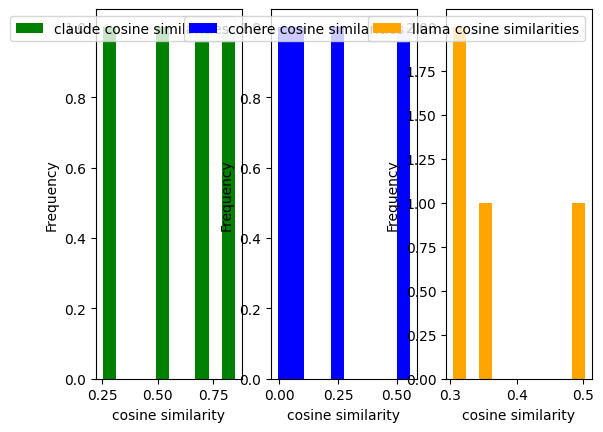

In [13]:

from IPython.display import display, HTML
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt


max_count = 19
num_to_eval = 4

lama_gt_cosine_sim = np.empty(num_to_eval)
cohere_gt_cosine_sim = np.empty(num_to_eval)
claude_gt_cosine_sim = np.empty(num_to_eval)

for index in range(num_to_eval):
    lama_gt_cosine_sim[index] = np.dot(
        gt_embeddings[index], lama_embeddings[index]
    ) / (norm(gt_embeddings[index]) * norm(lama_embeddings[index]))

    cohere_gt_cosine_sim[index] = np.dot(
        gt_embeddings[index], cohere_embeddings[index]
    ) / (norm(gt_embeddings[index]) * norm(cohere_embeddings[index]))

    claude_gt_cosine_sim[index] = np.dot(
        gt_embeddings[index], claude_embeddings[index]
    ) / (norm(gt_embeddings[index]) * norm(claude_embeddings[index]))


print(
    f"Cosine Similarity Score for Llama Answers are: {lama_gt_cosine_sim}"
)
print(
    f"Cosine Similarity Score for Cohere Answers are: {cohere_gt_cosine_sim}"
)
print(
    f"Cosine Similarity Score for Claude Answers are: {claude_gt_cosine_sim}"
)

ig, axs = plt.subplots(1, 3)
# plt.subplots_adjust(wspace=0.1)

plt.subplot(1, 3, 1)
plt.hist(claude_gt_cosine_sim, color="green")
plt.legend(["claude cosine similarities"])
plt.xlabel("cosine similarity")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(cohere_gt_cosine_sim, color="blue")
plt.legend(["cohere cosine similarities"])
plt.xlabel("cosine similarity")
plt.ylabel("Frequency")


plt.subplot(1, 3, 3)
plt.hist(lama_gt_cosine_sim, color="orange")
plt.legend(["llama cosine similarities"])
plt.xlabel("cosine similarity")
plt.ylabel("Frequency")
plt.show()

In [ ]:



#os.environ["LANGCHAIN_SESSION"] = "llm-grader"
from langchain.chat_models import BedrockChat
from langchain.evaluation.qa import QAEvalChain
import time
inference_modifier = {
    "max_tokens_to_sample": 545,
    "temperature": 0,
    "top_k": 250,
    "top_p": 1,
    "stop_sequences": ["\n\nHuman"],
}

llm = BedrockChat(model_id="anthropic.claude-v2", model_kwargs=inference_modifier)

eval_chain = QAEvalChain.from_llm(llm)

qa_list = [{'query': item['query'], 'answer': item['ground_truth']} for item in predictions]

print(qa_list)

## to avoid read timeouts split qa_list into chunks and execute eval_chain_evaluate function for each chunk with a wait period in betwwen
chunk_size = 50
graded_outputs = []
qa_chunks = [qa_list[i:i + chunk_size] for i in range(0, len(qa_list), chunk_size)]
qa_predictions = [predictions[i:i + chunk_size] for i in range(0, len(predictions), chunk_size)]

i = 0
print(f'Total # of chunks {len(qa_chunks)}')
while i < len(qa_chunks):
    print(f'starting chunk {i}')
    
    graded_output_chunk = eval_chain.evaluate(qa_chunks[i], qa_predictions[i], question_key = 'query', prediction_key = 'ground_truth')
    graded_outputs.append(graded_output_chunk)
    # wait between each chunk
    time.sleep(7000)
    print('inside try')
    
    i+=1

In [ ]:
import boto3
import json
import time
from botocore.config import Config

# Initialize Bedrock runtime client
config = Config(retries={'max_attempts': 8})
bedrock_runtime = boto3.client(
    service_name="bedrock-runtime",
    region_name="us-east-1",
    config=config
)

# Inference settings (same as before)
inference_modifier = {
    "max_tokens_to_sample": 545,
    "temperature": 0,
    "top_k": 250,
    "top_p": 1,
    "stop_sequences": ["\n\nHuman"]
}

# List of QA items you want to grade
qa_list = [{'query': item['query'], 'ground_truth': item['ground_truth'], 'llm_output': item['llm_output'], 'llm': item['llm'] } for item in predictions]

# Split into chunks to avoid timeouts
chunk_size = 50
qa_chunks = [qa_list[i:i + chunk_size] for i in range(0, len(qa_list), chunk_size)]
qa_predictions = [predictions[i:i + chunk_size] for i in range(0, len(predictions), chunk_size)]

graded_outputs = []

def grade_qa_pair_claude(question, ground_truth, prediction):
    prompt = f"""You are a helpful assistant grading a model's response to a question.

Question: {question}

Model Answer: {prediction}
Ground Truth Answer: {ground_truth}

STRICTLY only Grade whether the model's answer is CORRECT or INCORECT and also 2 digit floating point grade between 0-1 where 1 being heighest. 

STRICTLY follow result format and no other details in output
Result format sould be comma seperated CORRECT/INCORRECT, (numerical_rating)

for error or not applicable scenatio result format should be comma seperated INCORRECT, 0.00 and no other details or result tags.

Answer:"""

    body = {
        "prompt": f"\n\nHuman: {prompt}\n\nAssistant:",
        **inference_modifier
    }

    response = bedrock_runtime.invoke_model(
        modelId="anthropic.claude-v2",
        body=json.dumps(body),
        contentType="application/json",
        accept="application/json"
    )

    completion = json.loads(response['body'].read())
    return completion['completion'].strip()


# Main loop with delay to avoid timeouts
print(f"Total # of chunks: {len(qa_chunks)}")
for i, chunk in enumerate(qa_chunks):
    print(f"\nStarting chunk {i + 1}/{len(qa_chunks)}")
    print(chunk)

    chunk_results = []
    for j, qa in enumerate(chunk):
        llm_output = qa_predictions[i][j]["llm_output"]
        
        result = grade_qa_pair_claude(qa["query"], qa["ground_truth"], llm_output)

        #print(result)

        result = result.replace("<result>", "").replace("</result>", "")
        results_list = result.split(",")

        rating_extracted = results_list[1].replace("\n","").strip()
        evaluation_extracted = results_list[0].replace("\n","").strip()
      

        if len(results_list) > 1 and len(rating_extracted) < 5:
            evaluation = evaluation_extracted
            rating = rating_extracted
        else:
            evaluation = "INCORRECT"
            rating = "0"



        chunk_results.append({
            "question": qa["query"],
            "ground_truth": qa["ground_truth"],
            "llm": qa["llm"],
            "llm_output": llm_output,
            "evaluation": evaluation ,
            "rating": rating
        })


    graded_outputs.extend(chunk_results)
    print(f"Finished chunk {i + 1}")
    time.sleep(5)  # Wait a few seconds to prevent overload (7000 seconds = 2hrs, probably a typo)

# Now `graded_outputs` contains all your evaluation results
print(json.dumps(graded_outputs, indent=2))

Total # of chunks: 1

Starting chunk 1/1
[{'query': "Who is Amazon's Senior Vice President and General Counsel?", 'ground_truth': 'David A. Zapolsky is the Senior Vice President, General Counsel and Secretary', 'llm_output': '\n<question_answer>\nDavid A. Zapolsky\n</question_answer>', 'llm': 'anthropic.claude-v2'}, {'query': "Where are Amazon's international headquarters located?", 'ground_truth': 'Amazon owns and leases corporate headquarters in Washington’s Puget Sound region and Arlington, Virginia.', 'llm_output': "\n<question_answer>\nAmazon's international headquarters are located in Luxembourg according to the retriever source.\n</question_answer>", 'llm': 'anthropic.claude-v2'}, {'query': "How much outstanding borrowings is under Amazon's commercial paper program?", 'ground_truth': '$6.8 billion of borrowings outstanding under the commercial paper programs, as of December 31, 2022', 'llm_output': '\n<question_answer>\n$6.8 billion of borrowings outstanding under the commercial

In [64]:

# Converted list
llm_eval_predictions = []

for item in graded_outputs:
    llm_eval_predictions.append({
        "query": item.get("question", ""),
        "llm": item.get("llm", ""),
        "llm_output": item.get("llm_output", ""),
        "ground_truth": item.get("ground_truth", ""),
        "evaluationmetric": "LLM-assisted evaluation with Claude",
        "evaluation": item.get("evaluation"),
        "rating": item.get("rating")
    })

In [65]:
# export data 
llm_eval_run_df = pd.DataFrame(llm_eval_predictions)
llm_eval_run_df.to_csv('./eval_run_llm.csv', index=False)

In [66]:
####### llm evaluator ############

llm_eval_predictions_df = pd.DataFrame(llm_eval_predictions)

# get value of grouby column
llm_eval_predictions_df['llm'] = llm_eval_predictions_df['llm'].str.strip()
llm_eval_predictions_df['CORRECT_Count'] = llm_eval_predictions_df.groupby('llm')['evaluation'].transform(lambda x: (x == 'CORRECT').sum())
llm_eval_predictions_df['INCORRECT_Count'] = llm_eval_predictions_df.groupby('llm')['evaluation'].transform(lambda x: (x == 'INCORRECT').sum())
llm_eval_predictions_df['llm_eval_accuracy'] = llm_eval_predictions_df['CORRECT_Count'] / (llm_eval_predictions_df['CORRECT_Count'] + llm_eval_predictions_df['INCORRECT_Count'])
llm_eval_predictions_df['TOTAL_Count'] = llm_eval_predictions_df['CORRECT_Count'] + llm_eval_predictions_df['INCORRECT_Count']

# remove all columns from dataframe except columns TOTAL_Count, CORRECT_Count, INCORRECT_Count, llm_eval_accuracy
llm_eval_predictions_df = llm_eval_predictions_df[['llm','TOTAL_Count', 'CORRECT_Count', 'INCORRECT_Count', 'llm_eval_accuracy']]

#remove all duplicate rows from llm_eval_predictions_df
llm_eval_predictions_df = llm_eval_predictions_df.drop_duplicates()


####### cosine similarity ############


# Count the number of CORRECT and INCORRECT evaluations for each LLM and evaluation method
cosine_string_eval_predictions_df = pd.DataFrame(cosine_string_eval_predictions)

# get value of grouby column
cosine_string_eval_predictions_df['llm'] = cosine_string_eval_predictions_df['llm'].str.strip()
cosine_string_eval_predictions_df['CORRECT_Count'] = cosine_string_eval_predictions_df.groupby('llm')['score'].transform(lambda x: (x == 'CORRECT').sum())
cosine_string_eval_predictions_df['INCORRECT_Count'] = cosine_string_eval_predictions_df.groupby('llm')['score'].transform(lambda x: (x == 'INCORRECT').sum())
cosine_string_eval_predictions_df['cosine_eval_accuracy'] = cosine_string_eval_predictions_df['CORRECT_Count'] / (cosine_string_eval_predictions_df['CORRECT_Count'] + cosine_string_eval_predictions_df['INCORRECT_Count'])
cosine_string_eval_predictions_df['avg_cosine_similarity'] = cosine_string_eval_predictions_df.groupby('llm')['feedback'].transform(lambda x: pd.to_numeric(x).mean())
cosine_string_eval_predictions_df['TOTAL_Count'] = cosine_string_eval_predictions_df['CORRECT_Count'] + cosine_string_eval_predictions_df['INCORRECT_Count']

# remove all columns from dataframe except columns TOTAL_Count, CORRECT_Count, INCORRECT_Count, llm_eval_accuracy
cosine_string_eval_predictions_df = cosine_string_eval_predictions_df[['llm','TOTAL_Count', 'CORRECT_Count', 'INCORRECT_Count', 'cosine_eval_accuracy','avg_cosine_similarity']]

#remove all duplicate rows from llm_eval_predictions_df
cosine_string_eval_predictions_df = cosine_string_eval_predictions_df.drop_duplicates()

In [68]:
cosine_string_eval_predictions_df[['llm','avg_cosine_similarity']]

,llm,avg_cosine_similarity
0,anthropic.claude-v2,0.517389
8,cohere.command-text-v14,0.351914
16,amazon.titan-text-lite-v1,0.301405


In [69]:
llm_eval_predictions_df.head(4)

,llm,TOTAL_Count,CORRECT_Count,INCORRECT_Count,llm_eval_accuracy
0,anthropic.claude-v2,8,4,4,0.50
8,cohere.command-text-v14,8,4,4,0.50
16,amazon.titan-text-lite-v1,8,2,6,0.25


In [92]:
from rouge_score import rouge_scorer


scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def rouge_grader(llm_answer, ground_truth):
    scores = scorer.score(ground_truth, llm_answer)
    for metric, score in scores.items():
        score = score.fmeasure

    return score


rouge_eval_predictions = []
for prediction in predictions:
        evaluation_result = rouge_grader(prediction['llm_output'], prediction['ground_truth'])   

        rouge_eval_predictions.append({
                "query": prediction['query'],
                "llm": prediction['llm'],
                "llm_output": prediction['llm_output'],
                "ground_truth": prediction['ground_truth'],
                "context": prediction['context'],
                "evaluationmetric": "ROUGEL F1 Score",
                "score": round(evaluation_result,2)
            })
        

print(rouge_eval_predictions[1])

{'query': "Where are Amazon's international headquarters located?", 'llm': 'anthropic.claude-v2', 'llm_output': "\n<question_answer>\nAmazon's international headquarters are located in Luxembourg according to the retriever source.\n</question_answer>", 'ground_truth': 'Amazon owns and leases corporate headquarters in Washington’s Puget Sound region and Arlington, Virginia.', 'context': 'tem 2. Properties As of December 31, 2022, we operated the following facilities (in thousands): Description of Use Physical stores (2) Fulfillment, data centers, and other Fulfillment, data centers, and other Total ___________________ (1) For leased properties, represents the total leased space excluding sub-leased space. (2) This includes 611 North America and 32 International stores as of December 31, 2022. Segment Leased Square Footage (1) Owned Square Footage Location Office space Office space Physical stores (2) 30,611 23,956 22,881 291 391,598 148,146 617,483 6,792 1,802 662 — 22,058 12,613 43,927

In [93]:
# export data 
rouge_eval_run_df = pd.DataFrame(rouge_eval_predictions)
rouge_eval_run_df.to_csv('./eval_run_rouge.csv', index=False)

In [94]:
rouge_eval_run_df['llm'] = rouge_eval_run_df['llm'].str.strip()
rouge_eval_run_df['average_rouge'] = rouge_eval_run_df.groupby('llm')['score'].transform(lambda x: sum(x) / len(x))

rouge_eval_run_df = rouge_eval_run_df[['llm','average_rouge']]

rouge_eval_run_df = rouge_eval_run_df.drop_duplicates()

rouge_eval_run_df[['llm','average_rouge']]


,llm,average_rouge
0,anthropic.claude-v2,0.35000
8,cohere.command-text-v14,0.22250
16,amazon.titan-text-lite-v1,0.21875


In [ ]:
from bert_score  import score



def bert_grader(llm_answer, ground_truth):
    P, R, F1  = score(cands=[llm_answer], refs=[ground_truth], lang="en")

    return F1[0].item()


bert_eval_predictions = []
for prediction in predictions:
        evaluation_result = bert_grader(prediction['llm_output'], prediction['ground_truth'])   
        print(evaluation_result)
        bert_eval_predictions.append({
                "query": prediction['query'],
                "llm": prediction['llm'],
                "llm_output": prediction['llm_output'],
                "ground_truth": prediction['ground_truth'],
                "context": prediction['context'],
                "evaluationmetric": "BERT F1 Score",
                "score": round(evaluation_result,2)
            })
        

print(bert_eval_predictions[1])



In [119]:
# export data 
bert_eval_predictions = pd.DataFrame(bert_eval_predictions)
bert_eval_predictions.to_csv('./eval_run_bert.csv', index=False)

In [120]:
bert_eval_predictions['llm'] = bert_eval_predictions['llm'].str.strip()
bert_eval_predictions['average_bert'] = bert_eval_predictions.groupby('llm')['score'].transform(lambda x: sum(x) / len(x))

bert_eval_predictions = bert_eval_predictions[['llm','average_bert']]

bert_eval_predictions = bert_eval_predictions.drop_duplicates()

bert_eval_predictions[['llm','average_bert']]


,llm,average_bert
0,anthropic.claude-v2,0.8425
8,cohere.command-text-v14,0.8200
16,amazon.titan-text-lite-v1,0.8250


llm name: anthropic.claude-v2
llm name: cohere.command-text-v14
llm name: amazon.titan-text-lite-v1


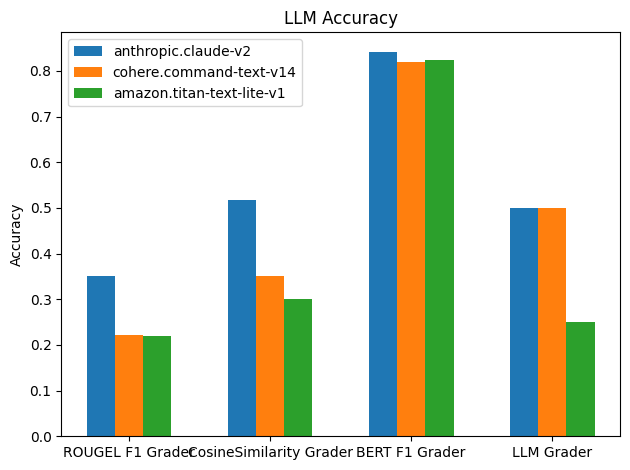

In [122]:
### 3f. visualize RAG system accuracy
# plot each row' accuracy column in overall_accuracy with matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = ["ROUGEL F1 Grader","CosineSimilarity Grader", "BERT F1 Grader", "LLM Grader"]
dataprep = []
for index, row in llm_eval_predictions_df.iterrows():
    llm_name = row['llm']
    print(f'llm name: {llm_name}')

    result1_df = rouge_eval_run_df[rouge_eval_run_df['llm'] == llm_name]
    value1 = result1_df.loc[index, 'average_rouge']

    result2_df = cosine_string_eval_predictions_df[cosine_string_eval_predictions_df['llm'] == llm_name]
    value2 = result2_df.loc[index, 'avg_cosine_similarity']

    result3_df = bert_eval_predictions[bert_eval_predictions['llm'] == llm_name]
    value3 = result3_df.loc[index, 'average_bert']
    
    dataprep.append([llm_name, pd.to_numeric(value1), pd.to_numeric(value2), pd.to_numeric(value3), pd.to_numeric(row['llm_eval_accuracy'])])

data = {
    'EvaluationMethod': categories,
    dataprep[0][0] : dataprep[0][1:],
    dataprep[1][0]: dataprep[1][1:],
    dataprep[2][0]: dataprep[2][1:]
}

df = pd.DataFrame(data)

# Set the width of the bars and the number of series
num_series = len(df.columns) - 1  # Subtract 1 to exclude the 'Category' column
bar_width = 0.2
bar_positions = np.arange(len(df))

# Create a figure and axis
fig, ax = plt.subplots()

# Plot each series
for i, col in enumerate(df.columns[1:]):
    offset = (i - (num_series - 1) / 2) * bar_width
    ax.bar(bar_positions + offset, df[col], width=bar_width, label=col)

# Set x-axis labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(df['EvaluationMethod'])

# Labeling and legend
#ax.set_xlabel('Model Evaluation')
ax.set_ylabel('Accuracy')
ax.set_title('LLM Accuracy')
ax.legend()

# Show the chart
plt.tight_layout()  # Optional: Adjust layout for better spacing
plt.show()